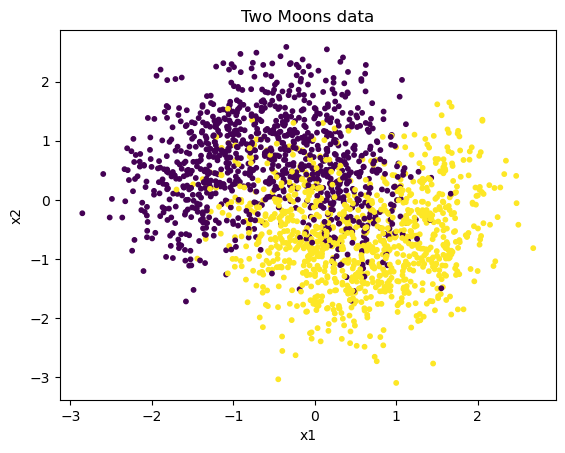

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# two moons data

X, y = make_moons(
    n_samples=2000,
    noise=0.4,
    random_state=1
)
X = StandardScaler().fit_transform(X)

plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Moons data")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1, stratify=y
)

In [2]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# transform data into tensors

torch.manual_seed(1)

X_train_tensor = torch.tensor(
    X_train, dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train, dtype=torch.float32
).reshape(-1, 1)

X_test_tensor = torch.tensor(
    X_test, dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test, dtype=torch.float32
).reshape(-1, 1)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [3]:
# define neural network

class MoonNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x)

model = MoonNet()
print(model)

MoonNet(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


Epoch   5, loss = 0.3895
Epoch  10, loss = 0.3869
Epoch  15, loss = 0.3851
Epoch  20, loss = 0.3834
Epoch  25, loss = 0.3823
Epoch  30, loss = 0.3792
Epoch  35, loss = 0.3731
Epoch  40, loss = 0.3635
Epoch  45, loss = 0.3523
Epoch  50, loss = 0.3425
Epoch  55, loss = 0.3369
Epoch  60, loss = 0.3335
Epoch  65, loss = 0.3347
Epoch  70, loss = 0.3310
Epoch  75, loss = 0.3321
Epoch  80, loss = 0.3317
Epoch  85, loss = 0.3308
Epoch  90, loss = 0.3314
Epoch  95, loss = 0.3308
Epoch 100, loss = 0.3318
Epoch 105, loss = 0.3309
Epoch 110, loss = 0.3327
Epoch 115, loss = 0.3307
Epoch 120, loss = 0.3302
Epoch 125, loss = 0.3311
Epoch 130, loss = 0.3303
Epoch 135, loss = 0.3300
Epoch 140, loss = 0.3299
Epoch 145, loss = 0.3304
Epoch 150, loss = 0.3314
Epoch 155, loss = 0.3310
Epoch 160, loss = 0.3308
Epoch 165, loss = 0.3314
Epoch 170, loss = 0.3295
Epoch 175, loss = 0.3294
Epoch 180, loss = 0.3296
Epoch 185, loss = 0.3308
Epoch 190, loss = 0.3295
Epoch 195, loss = 0.3299
Epoch 200, loss = 0.3291


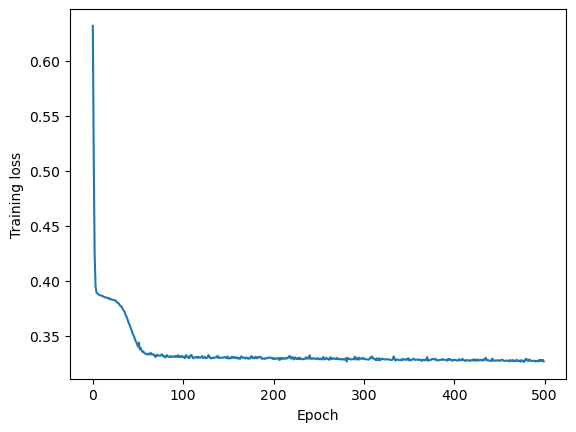

In [4]:
# train model

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 500
loss_history = []

for epoch in range(num_epochs):

    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(X_batch)

    average_loss = total_loss / len(train_dataset)
    loss_history.append(average_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:3d}, "
            f"loss = {average_loss:.4f}"
        )

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.show()

In [5]:
# test model

model.eval()

with torch.no_grad():

    test_logits = model(X_test_tensor)
    test_pred = (test_logits >= 0.0).float()
    test_accuracy = (test_pred == y_test_tensor).float().mean()

print("Test accuracy:", test_accuracy.item())

Test accuracy: 0.8460000157356262


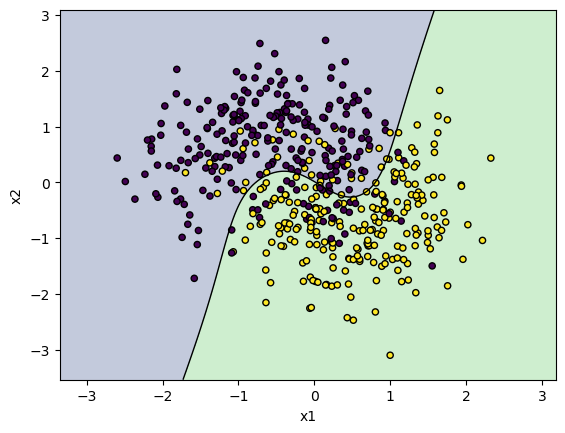

In [6]:
# decision boundary

x1_min, x1_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
x2_min, x2_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 500), np.linspace(x2_min, x2_max, 500))
grid_tensor = torch.tensor(np.c_[xx1.ravel(), xx2.ravel()], dtype=torch.float32)

model.eval()
with torch.no_grad():
    grid_prob = torch.sigmoid(model(grid_tensor)).numpy().reshape(xx1.shape)

plt.contourf(xx1, xx2, grid_prob, levels=[0, 0.5, 1], alpha=0.3)
plt.contour(xx1, xx2, grid_prob, levels=[0.5], colors='black', linewidths=1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=20, edgecolors="black")

plt.xlabel("x1")
plt.ylabel("x2")
plt.show()